# 04. Green Spaces Analysis

This notebook explores the recreational areas in Nørrebro: Parks and Playgrounds.

**Data Sources:**
- **Green Spaces**: `data/processed/norrebro_greenspaces.gpkg` (contains 'parks' and 'playgrounds' layers).
- **Boundary**: `data/processed/norrebro_boundary.gpkg`.

**Goals:**
1. **Types**: Visualize the distribution of park types.
2. **Playgrounds**: Map playground locations relative to parks.
3. **Coverage**: Estimate the area/population within 300m of a green space.

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from src.visualization import style
import contextily as ctx

style.apply_style()

## 1. Load Data

In [3]:
data_dir = project_root / "data" / "processed"

gdf_parks = gpd.read_file(data_dir / "norrebro_greenspaces.gpkg", layer="parks")
gdf_play = gpd.read_file(data_dir / "norrebro_greenspaces.gpkg", layer="playgrounds")
gdf_bound = gpd.read_file(
    data_dir / "norrebro_boundary.gpkg", layer="norrebro_boundary"
)

print(f"Parks Count: {len(gdf_parks)}")
print(f"Playgrounds Count: {len(gdf_play)}")

Parks Count: 77
Playgrounds Count: 34


## 2. Park Types
Distribution of green spaces by category (`park_type`).

In [4]:
gdf_parks.head()

,area_id,park_id,area_name,park_number,park_type,park_name,sub_name,district,ownership_type,owner,...,development_year,visitor_count,user_surveys,description,link,catchment_pop_300m,catchment_pop_875m,registration_date,correction_date,geometry
0,1371,30.0,Søerne,30,Regionale parker,Søerne,Søerne,Indre by,Københavns Kommune,TMF,...,None,None,Nej,"Indre Søer udgør et gennemgående, bueformet va...",None,31230.0,88834.0,None,None,"MULTIPOLYGON (((724494.868 6177497.282, 724501..."
1,1367,30.0,Søerne,30,Vandflader,Søerne,Søerne,Indre by,Københavns Kommune,TMF,...,None,None,Nej,"Indre Søer udgør et gennemgående, bueformet va...",None,32145.0,88183.0,None,None,"MULTIPOLYGON (((724512.532 6177527.539, 724517..."
2,1395,38.0,H.C. Ørstedsparken,38,Regionale parker,Ørstedsparken,H. C. Ørstedsparken,Indre by,Københavns Kommune,TMF,...,None,None,Nej,NaN,None,7095.0,25232.0,None,None,"MULTIPOLYGON (((724280.125 6176494.11, 724279...."
3,1388,38.0,H.C. Ørstedparken,38,Vandflader,Ørstedsparken,Ørstedsparken,Indre by,Københavns Kommune,TMF,...,None,None,Nej,NaN,None,5728.0,21967.0,None,None,"MULTIPOLYGON (((724301.31 6176455.795, 724300...."
4,1379,30.0,Søerne,30,Regionale parker,Søerne,Søerne,Nørrebro,Københavns Kommune,TMF,...,None,None,Nej,"Indre Søer udgør et gennemgående, bueformet va...",None,13333.0,42565.0,None,None,"MULTIPOLYGON (((723938.352 6177023.412, 723940..."


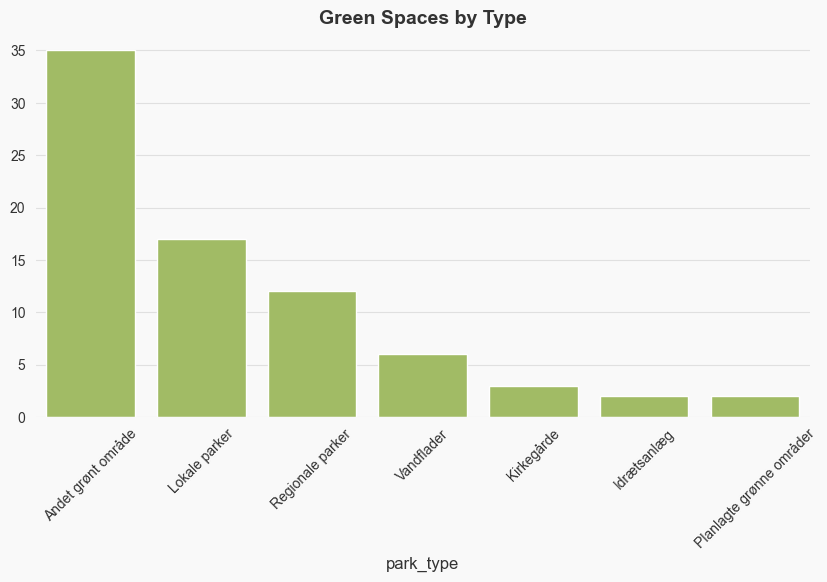

In [5]:
if "park_type" in gdf_parks.columns:
    type_counts = gdf_parks["park_type"].value_counts()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=type_counts.index, y=type_counts.values, color=style.PALETTE["park"])
    plt.title("Green Spaces by Type")
    plt.xticks(rotation=45)
    sns.despine()
    plt.show()

## 3. Map: Parks & Playgrounds

In [17]:
# create an english version of the park types
park_type_danish = [
    "Regionale parker",
    "Vandflader",
    "Andet grønt område",
    "Kirkegårde",
    "Lokale parker",
    "Idrætsanlæg",
    "Planlagte grønne områder",
]
park_type_english = [
    "Regional Parks",
    "Water Bodies",
    "Other Green Spaces",
    "Cemeteries",
    "Local Parks",
    "Sports Facilities",
    "Planned Green Spaces",
]
park_type_mapping = dict(zip(park_type_danish, park_type_english))
gdf_parks["park_type_en"] = gdf_parks["park_type"].map(park_type_mapping)

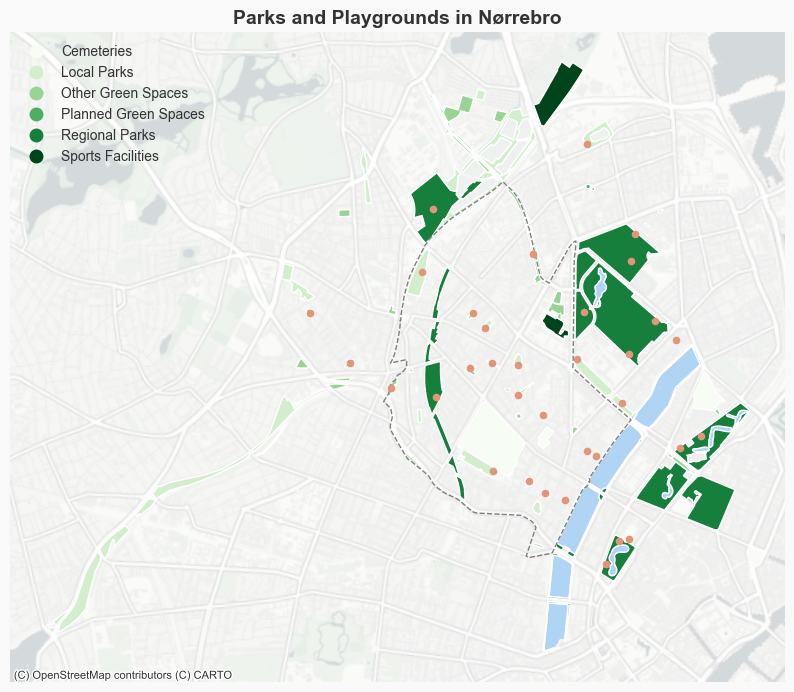

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

# 'water' bodies bodies should be in blue
gdf_parks[gdf_parks["park_type_en"] == "Water Bodies"].plot(
    ax=ax, color=style.PALETTE["water"], alpha=0.7, label="Water Bodies"
)

# Parks
gdf_parks[gdf_parks["park_type_en"] != "Water Bodies"].plot(
    ax=ax,
    column="park_type_en",
    # Use a green colormap for parks but start from a darker shade
    cmap="Greens",
    legend=True,
    label="Parks",
)

# Playgrounds
gdf_play.plot(
    ax=ax,
    color=style.PALETTE["accent_warm"],
    markersize=20,
    label="Playgrounds",
    zorder=2,
)

# Background: Nørrebro Boundary
gdf_bound.plot(ax=ax, facecolor="none", edgecolor="grey", linestyle="--")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax.set_title("Parks and Playgrounds in Nørrebro")
ax.set_axis_off()
plt.show()

## 4. Coverage Mapping (based on pre calculated data from source)
plotting bot cols = catchment_pop_300m and catchment_pop_875m

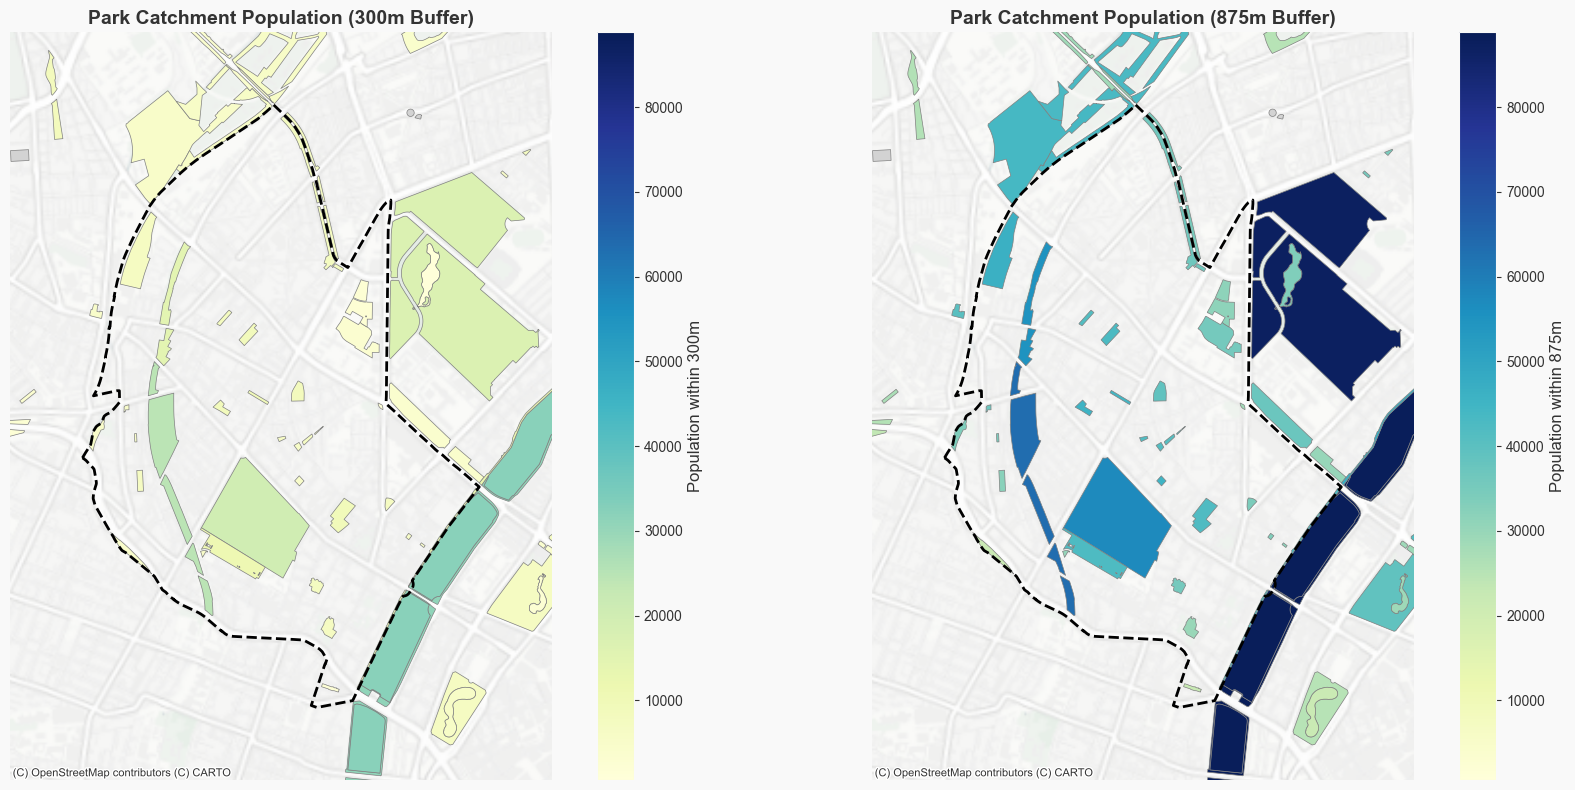

In [29]:
# Calculate common min/max for consistent color scale
vmin = min(gdf_parks["catchment_pop_300m"].min(), gdf_parks["catchment_pop_875m"].min())
vmax = max(gdf_parks["catchment_pop_300m"].max(), gdf_parks["catchment_pop_875m"].max())

bbox = gdf_bound.buffer(400).total_bounds

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map 1: 300m catchment
gdf_parks.plot(
    ax=axes[0],
    column="catchment_pop_300m",
    cmap="YlGnBu",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={"label": "Population within 300m"},
    edgecolor="grey",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)
gdf_bound.plot(
    ax=axes[0], facecolor="none", edgecolor="black", linestyle="--", linewidth=2
)

ctx.add_basemap(
    axes[0], source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832"
)
axes[0].set_title("Park Catchment Population (300m Buffer)")
axes[0].set_axis_off()
axes[0].set_xlim(bbox[0], bbox[2])
axes[0].set_ylim(bbox[1], bbox[3])

# Map 2: 875m catchment
gdf_parks.plot(
    ax=axes[1],
    column="catchment_pop_875m",
    cmap="YlGnBu",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={"label": "Population within 875m"},
    edgecolor="grey",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)
gdf_bound.plot(
    ax=axes[1], facecolor="none", edgecolor="black", linestyle="--", linewidth=2
)

ctx.add_basemap(
    axes[1], source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832"
)
axes[1].set_title("Park Catchment Population (875m Buffer)")
axes[1].set_axis_off()
axes[1].set_xlim(bbox[0], bbox[2])
axes[1].set_ylim(bbox[1], bbox[3])

plt.tight_layout()
plt.show()